# `Feature Scaling`

Feature scaling is the process of **bringing numerical features to a similar scale** so that no feature dominates others simply because it has larger values. It changes only the scale of the data, not the relationships between data points.

### Why do we need it?

Many machine learning algorithms use **distances** or **gradient descent** during training. If one feature ranges from 1–10 and another from 1–1,000,000, the larger feature will have a much greater influence on calculations, even if it isn't more important. Scaling ensures every feature contributes fairly, allowing the model to learn from the data rather than from the size of the numbers.

### What if we don't use it?

Without feature scaling, algorithms like KNN, K-Means, SVM, and Linear/Logistic Regression (using gradient descent) may become biased toward large-valued features. Gradient descent also converges much more slowly because the optimization path becomes stretched and inefficient. Tree-based models like Decision Trees and Random Forests generally do **not** require feature scaling.

---

# Types of Feature Scaling

## 1. Normalization `(Min-Max Scaling)`

**Formula**

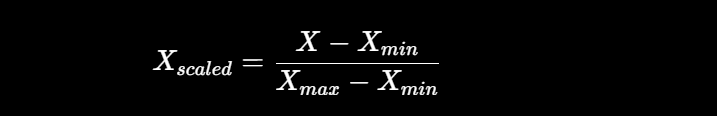

Normalization rescales values to a fixed range, usually **0 to 1**. The smallest value becomes 0, the largest becomes 1, and all other values are placed proportionally between them. It is useful when algorithms expect bounded input values, such as Neural Networks. However, it is sensitive to outliers because the minimum and maximum determine the scale.

---

## 2. Standardization `(Z-Score Scaling)`

**Formula**

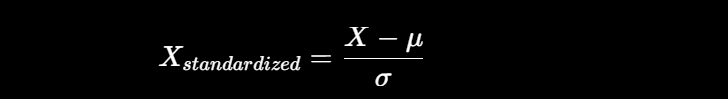

where **μ** is the mean and **σ** is the standard deviation.

Standardization transforms data so that it has a **mean of 0** and a **standard deviation of 1**. Instead of using minimum and maximum values, it measures how far each value is from the average. It is less affected by outliers than normalization and is commonly used with Linear Regression, Logistic Regression, SVM, and PCA.




# StandardScaler

`StandardScaler` is a Scikit-learn class used to **standardize features**, i.e., transform them so that each feature has:

* **Mean (μ) = 0**
* **Standard Deviation (σ) = 1**

It applies the standardization formula:

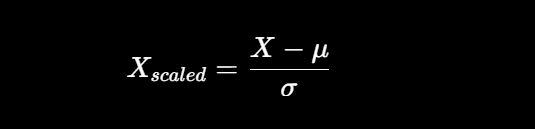

---

## Why do we use `fit()`?

`fit()` **does not change the data.** It only **learns** the statistics needed for scaling.

Specifically, it calculates:

* Mean (μ)
* Standard Deviation (σ)

for every feature in the **training data**.

Example:

```python
Age
20
30
40
50
```

After

```python
scaler.fit(X_train)
```

the scaler simply stores

```python
Mean = 35
Std Dev = 11.18
```

Nothing has been transformed yet.

Think of `fit()` as **studying the training data**.

---

## Why do we use `transform()`?

`transform()` uses the mean and standard deviation computed by `fit()` to actually scale the data.

Example:

```python
X_test = scaler.transform(X_test)
```

If a test value is

```python
45
```

then

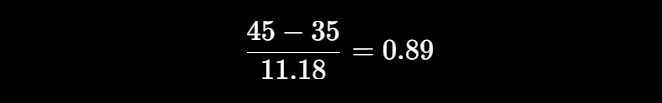

The transformed value becomes **0.89**.

Think of `transform()` as **applying what was learned**.

---

## Why do we use `fit_transform()`?

Since we almost always want to **learn the statistics and immediately scale the training data**, Scikit-learn combines both steps into one method.

```python
X_train = scaler.fit_transform(X_train)
```

This is exactly equivalent to

```python
scaler.fit(X_train)
X_train = scaler.transform(X_train)
```

It is simply shorter and more convenient.

---

## Why don't we use `fit_transform()` on the test set?

This is one of the most important rules in Machine Learning.

The test set represents **unseen data**. During training, the model must not know anything about it.

If you write

```python
X_test = scaler.fit_transform(X_test)
```

the scaler calculates a **new mean and standard deviation from the test data**.

Now the model has indirectly learned information about the test set before evaluation.

This is called **data leakage**, and it makes the evaluation unreliable because the model is no longer being tested on truly unseen data.

---

## The correct workflow

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # Learn μ and σ, then scale
X_test = scaler.transform(X_test)         # Use the same μ and σ
```

The training data defines the scaling. The test data **must follow the same scaling**, otherwise the model sees features in a different representation than the one it was trained on.

---
